In [ ]:
import os
import sys

import pandas as pd

sys.path.append("..")
from src.cleaning import clean_patients

os.makedirs("../data/processed", exist_ok=True)

patients = clean_patients(pd.read_csv("../data/raw/patients.csv"))

patients.head(5)

patients.info()
patients.isna().sum()
patients['GENDER'].value_counts()
patients['MARITAL'].value_counts()
patients['STATE'].value_counts()
patients["CITY"].nunique()
patients.iloc[0]

# how many patients are there?
totalrows = len(patients)
# How many columns?
len(patients.columns)

#  columns with missing values?
null_status = (patients.isna().sum()) > 0
null_status[null_status > 0]

# what are the different martial statuses?
patients['MARITAL'].unique()

# display only the specfic columns of the patient
patients.iloc[0][['FIRST', 'GENDER', 'MARITAL', 'STATE', 'CITY']]

patients.dtypes

patients[['BIRTHDATE', 'age']].head()
patients['age'].min()
patients['age'].max()
patients['age'].describe()

# patients age less than 1
patients[patients['age'] < 1][['BIRTHDATE', 'age']].head()
# can we have a patiente who is 300 years old or negative? validate it
patients[(patients['age'] >= 300) | (patients['age'] < 0)][['BIRTHDATE', 'age']].head()
# check if missing values in specfic columns
patients['DEATHDATE'].isna().sum()
# filter
(patients['age'] >= 65).sum()
patients[(patients["GENDER"] == "F") & (patients["age"] >= 65)]


<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Id                   108 non-null    str           
 1   BIRTHDATE            108 non-null    datetime64[us]
 2   DEATHDATE            9 non-null      datetime64[us]
 3   SSN                  108 non-null    str           
 4   DRIVERS              85 non-null     str           
 5   PASSPORT             78 non-null     str           
 6   PREFIX               82 non-null     str           
 7   FIRST                108 non-null    str           
 8   MIDDLE               82 non-null     str           
 9   LAST                 108 non-null    str           
 10  SUFFIX               1 non-null      str           
 11  MAIDEN               19 non-null     str           
 12  MARITAL              65 non-null     str           
 13  RACE                 108 non-null    str      

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,age,age_group
14,7ad140ab-bfae-c3ae-20a3-2244b1c4d0e2,1954-04-26,2024-04-06,999-45-5584,S99953961,X81925810X,Ms.,Guadalupe206,NaN,Valencia279,...,Suffolk County,25025.0,2136,42.385695,-71.052321,60536.96,1319993.71,8437,72.3,elder
26,8d7f6a31-31ba-da9c-2b57-03ee0f7577a0,1954-04-26,NaT,999-28-8059,S99948245,X55920706X,Mrs.,Eloisa55,Cristina921,Sanabria449,...,Suffolk County,25025.0,2120,42.336418,-71.075056,28978.71,1495032.66,8437,72.3,elder
33,ad41b3b5-b5a1-f136-af92-bc03052fba86,1959-10-05,NaT,999-69-8613,S99978639,X67363144X,Mrs.,Lashonda618,Lu473,McLaughlin530,...,Hampshire County,25015.0,1027,42.303526,-72.731717,1016959.85,183764.34,88313,66.9,elder
73,2eb14889-46f2-06de-4f6e-fea5634e0d85,1943-07-11,NaT,999-31-3387,S99925233,X61539217X,Mrs.,Chasidy481,Ellis535,Grant908,...,Middlesex County,25017.0,2476,42.385759,-71.199090,228204.52,748398.65,33871,83.1,elder
77,7c50e28d-07cc-a4cf-eb58-b2a15bc552a3,1960-03-14,2014-10-23,999-66-7226,S99954067,X94171630X,Mrs.,Margot418,Otha286,Strosin214,...,Middlesex County,25017.0,1852,42.629825,-71.317423,770045.03,236301.86,56556,66.4,elder
79,20447ad5-5095-fb78-2bd9-69bf39242b4a,1957-09-05,2020-04-07,999-10-5439,S99975342,X04583806X,Mrs.,Ebony669,NaN,Ziemann98,...,Middlesex County,25017.0,2474,42.391718,-71.220222,285033.65,452331.56,752427,69.0,elder
81,4d5bd8b4-8ee1-c357-dd1d-6bca1c275f56,1960-03-14,NaT,999-83-6149,S99995483,X77692369X,Ms.,Shirl54,Paola523,Mohr916,...,Middlesex County,25017.0,1851,42.597888,-71.351340,811398.10,537453.17,56556,66.4,elder
88,9277390b-8a92-52e1-4d99-bb4849bac775,1957-09-05,NaT,999-98-4397,S99934218,X65348626X,Mrs.,Ursula220,Hildegarde627,Doyle959,...,Middlesex County,25017.0,2476,42.460718,-71.132395,288981.60,935696.34,752427,69.0,elder
97,53e4891a-9108-67ef-d973-3b6a98404249,1951-08-01,NaT,999-55-1703,S99919812,X04397292X,Mrs.,Georgiann138,NaN,Dickinson688,...,Middlesex County,25017.0,1852,42.698007,-71.291331,367790.43,831802.38,156940,75.0,elder


<Axes: title={'center': 'Patient Age Distribution'}, xlabel='age_group'>

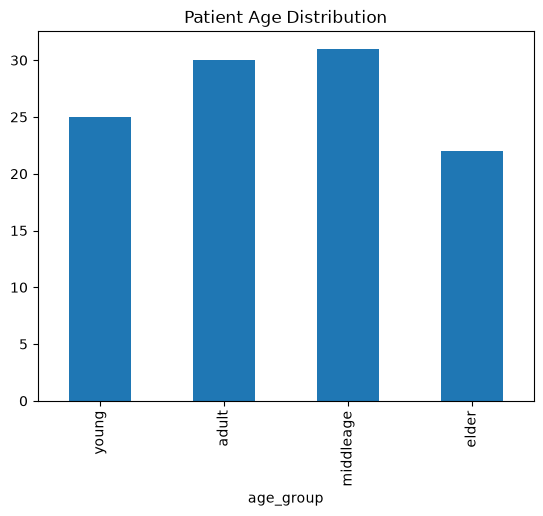

In [ ]:
# check age_group created by clean_patients() -- see src/cleaning.py
patients[["age", "age_group"]].head(10)

patients['age_group'].value_counts()

# how are patients distributed accross age groups
age_distribution = (
    patients['age_group']
    .value_counts()
    .sort_index()
)
age_distribution.plot(
    kind = "bar",
    title = "Patient Age Distribution"
)


In [3]:
# data quality checks
patients['Id'].isna().sum()
patients['Id'].duplicated().sum()

((patients["age"] > 120) | (patients["age"] < 0)).sum()

patients['GENDER'].isna().sum()

np.int64(0)

In [4]:
# Patient Demographic Report

total_patients = len(patients)
print(f"Total patients are: {total_patients}")

average_age = patients['age'].mean()
print(f"Average Age of the Patients is: {average_age}")

median_age =  patients['age'].median()
print(f"the exact meddle number in the patients age data is: {median_age}")

youngest_patient_name = patients.loc[patients["age"].idxmin(), "FIRST"]
print(f"The youngest patient is called {youngest_patient_name}")


oldest_patient = patients.loc[patients["age"].idxmax(), "FIRST"]
print(f"The oldest patient is called {oldest_patient}")

total_death = patients['DEATHDATE'].notna().sum()
print(f"Total patients who passed away: {total_death}")

Total patients are: 108
Average Age of the Patients is: 38.67777777777778
the exact meddle number in the patients age data is: 38.900000000000006
The youngest patient is called Kayleigh718
The oldest patient is called Dominic463
Total patients who passed away: 9


In [5]:

# create the cleaned patients csv for other notebooks to reuse
patients.to_csv("../data/processed/patients_cleaned.csv", index=False)
print("Cleaned patient data saved to data/processed/patients_cleaned.csv")

Cleaned patient data saved to data/processed/patients_cleaned.csv
